In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import logging
import multiprocess as mp
import soundfile as sf
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from cachetools import cached
from sklearn.metrics import classification_report, confusion_matrix
import warnings
from multiprocessing import Pool, cpu_count
from functools import partial

warnings.filterwarnings("ignore")
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
BASE_DIR = "./Dataset"
LANGUAGES = ("German", "Italian", "Korean", "Spanish")

In [3]:
@cached(cache={})
def load_audio(file_path: str, sr=16000):
    signal, sample_rate = librosa.load(file_path, sr=sr)
    return signal, sample_rate


def load_df() -> pd.DataFrame:
    return_data = []
    for language in LANGUAGES:
        path = os.path.join(BASE_DIR, language)
        genders = os.listdir(path)
        for gender in genders:
            dir_path = os.path.join(path, gender)
            if not os.path.isdir(dir_path):
                logging.warning(
                    f"Expected directory but found file: {dir_path}. Skipping."
                )
                continue
            audio_files = os.listdir(dir_path)
            for audio_file in audio_files:
                audio_path = os.path.join(dir_path, audio_file)
                return_data.append(
                    {
                        "language": language,
                        "gender": gender,
                        "audio_path": audio_path,
                    }
                )
    return pd.DataFrame(return_data)


df = load_df()

In [4]:
@cached(cache={})
def get_mfccs(path: str, n_features=13):
    audio, sr = load_audio(path)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_features)
    mfccs = np.mean(mfccs.T, axis=0)
    return mfccs


@cached(cache={})
def get_mel_spectrogram(path: str, n_features=128):
    audio, sr = load_audio(path)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_features)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_spec_db = np.mean(mel_spec_db.T, axis=0)
    return mel_spec_db

def run_parallel(func, paths, n_features):
    n_jobs = cpu_count() - 1
    if n_jobs < 1:
        n_jobs = 1
    with mp.Pool(processes=n_jobs) as pool:
        results = list(
            tqdm(
                pool.imap(partial(func, n_features=n_features), paths),
                total=len(paths),
                desc=f"Extracting features with {func.__name__}",
            )
        )
    results = [r for r in results if r is not None]
    return np.array(results)

In [5]:
audio, sample_rate = load_audio(df["audio_path"][0])
print(f"Audio shape: {audio.shape}, Sample rate: {sample_rate}")
mfccs = get_mfccs(df["audio_path"][0])
print(f"MFCCs shape: {mfccs.shape}")
mel_spectrogram = get_mel_spectrogram(df["audio_path"][0])
print(f"Mel Spectrogram shape: {mel_spectrogram.shape}")
stft = librosa.stft(audio)

Audio shape: (957600,), Sample rate: 16000
MFCCs shape: (13,)
Mel Spectrogram shape: (128,)


Extracting features with get_mel_spectrogram: 100%|██████████| 720/720 [00:21<00:00, 33.45it/s]


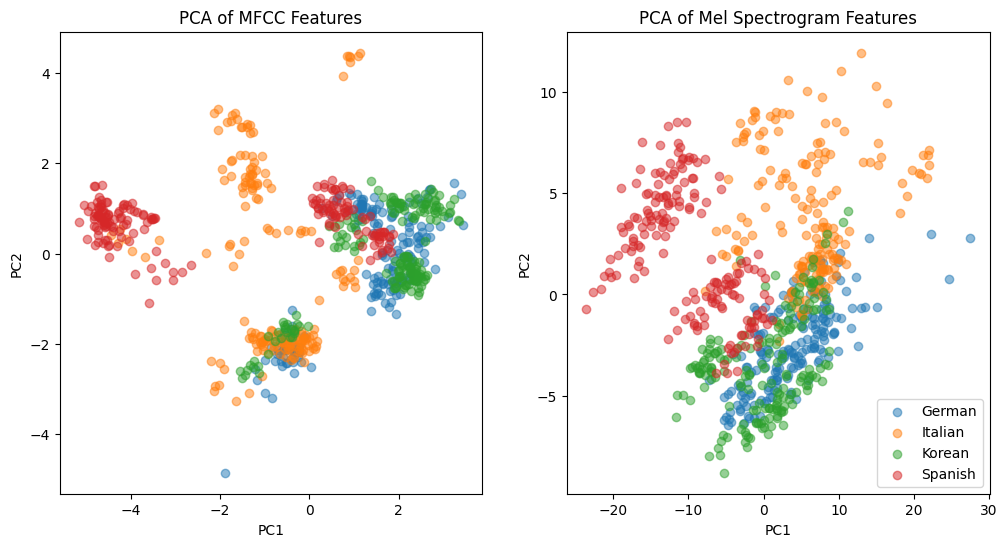

In [6]:
X_mfccs = run_parallel(get_mfccs, df["audio_path"].tolist(), n_features=13)
X_mel_specs = run_parallel(get_mel_spectrogram, df["audio_path"].tolist(), n_features=128)

X_mfccs = StandardScaler().fit_transform(X_mfccs)
X_mel_specs = StandardScaler().fit_transform(X_mel_specs)

pca = PCA(n_components=2)
X_mfccs = pca.fit_transform(X_mfccs)
X_mel_specs = pca.fit_transform(X_mel_specs)

plt.figure(figsize=(12, 6))
for language in LANGUAGES:
    idx = df["language"] == language
    plt.subplot(1, 2, 1)
    plt.scatter(X_mfccs[idx, 0], X_mfccs[idx, 1], label=language, alpha=0.5)
    plt.subplot(1, 2, 2)
    plt.scatter(X_mel_specs[idx, 0], X_mel_specs[idx, 1], label=language, alpha=0.5)


for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    if i == 0:
        plt.title("PCA of MFCC Features")
    else:
        plt.title("PCA of Mel Spectrogram Features")
plt.legend()
plt.show()